In [1]:
import os
from pathlib import Path

data_dir = Path(
    "/home/qhe2/Documents/Datasets/tcia/test/"
)

model_dir = Path(
    "models/.totalsegmentator/nnunet/results/nnUNet/2d/Task927_FatMuscle/nnUNetTrainerV2__nnUNetPlansv2.1"
)

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

In [2]:
import torch
from nnunet.training.model_restore import restore_model
from typing import cast

checkpoint_dir = model_dir / "all"
checkpoint_file = checkpoint_dir / "model_final_checkpoint.model"
checkpoint_pkl = checkpoint_dir / "model_final_checkpoint.model.pkl"

# 1. Restore trainer config only
trainer = restore_model(
    str(checkpoint_pkl),
    checkpoint=None,
    train=False,
    fp16=None,
)

# 2. Redirect nnUNet's writable paths away from the original training machine
tmp_out = Path.cwd() / ".nnunet_tmp"
tmp_out.mkdir(parents=True, exist_ok=True)

trainer.output_folder = str(tmp_out)
trainer.output_folder_base = str(tmp_out)
trainer.fold = "all"
trainer.log_file = None

# Optional, sometimes helpful if dataset paths were serialized too
if hasattr(trainer, "dataset_directory"):
    trainer.dataset_directory = str(tmp_out)

# 3. Now load weights
trainer.load_checkpoint(str(checkpoint_file), train=False)

model = cast(torch.nn.Module, trainer.network)
model = model.eval().cuda()



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

nnUNet_raw_data_base is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
RESULTS_FOLDER is not defined and nnU-Net cannot be used for training or inference. If this is not in

/home/qhe2/Applications/miniconda3/envs/Comp2Comp/lib/python3.11/site-packages/nnunet/training/network_training/network_trainer.py:404: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_grad_scaler = GradScaler()


In [3]:
from data import TCIA

dataset = TCIA(data_dir, batch_size=1, img_size=256)

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/home/qhe2/Applications/miniconda3/envs/Comp2Comp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1776717946.529383 1363323 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
image, mask = dataset[0]

In [5]:
image.shape, mask.shape

(torch.Size([1, 256, 256]), torch.Size([1, 256, 256]))

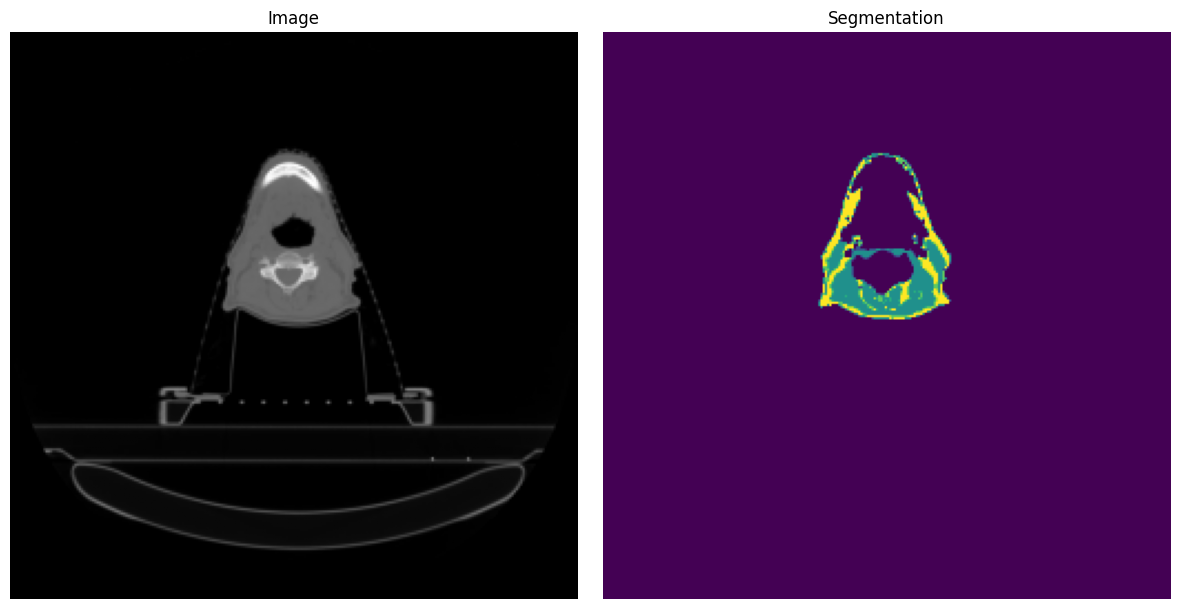

In [6]:
from matplotlib import pyplot as plt
%matplotlib inline

image_np = image.detach().cpu().permute(2,1,0).squeeze().numpy()
segmentation_np = mask.detach().cpu().permute(2,1,0).squeeze().numpy()

if image_np.ndim == 3:
    slice_idx = image_np.shape[0] // 2
    image_slice = image_np[slice_idx]
elif image_np.ndim == 2:
    image_slice = image_np
else:
    raise ValueError(f"Unsupported image shape: {image_np.shape}")

if segmentation_np.ndim == 3:
    segmentation_slice = segmentation_np[slice_idx]
elif segmentation_np.ndim == 2:
    segmentation_slice = segmentation_np
else:
    raise ValueError(f"Unsupported segmentation shape: {segmentation_np.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_slice, cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(segmentation_slice)
axes[1].set_title("Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
x = image.cuda().unsqueeze(0)

In [14]:
y: torch.Tensor = model(x)[0]
y = y[0].softmax(0) > 0.5

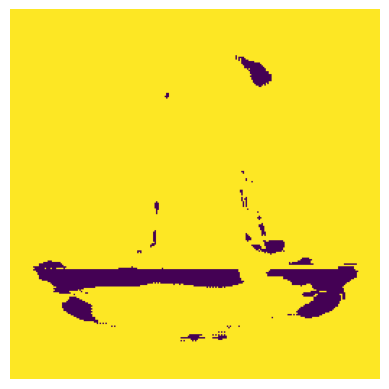

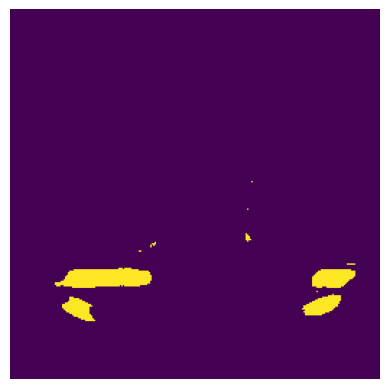

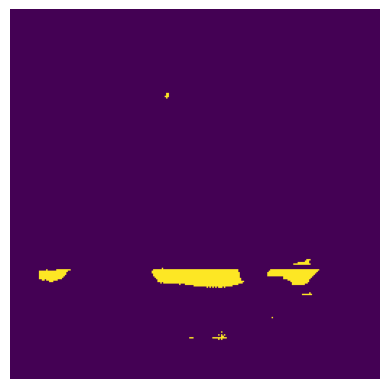

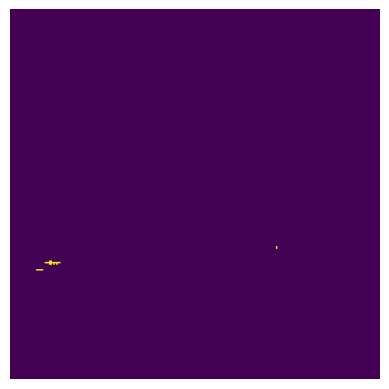

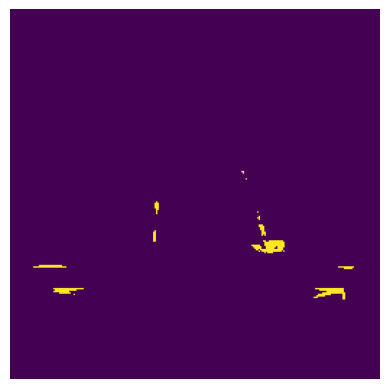

In [15]:
for m in y:
    m = m.detach().cpu().permute(1,0).squeeze().numpy()
    plt.imshow(m)
    plt.axis("off")
    plt.show()